# Heart disease Predicition

In [ ]:
import pandas as pd # Import pandas for data manipulation
import numpy as np # Import numpy for numerical operations
import matplotlib.pyplot as plt # Import matplotlib for plotting
import seaborn as sns # Import seaborn for enhanced visualizations
from sklearn.linear_model import LogisticRegression # Import Logistic Regression model
from sklearn.model_selection import train_test_split # Import train_test_split for splitting data
from sklearn.metrics import classification_report, confusion_matrix # Import metrics for model evaluation

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/cap/heart.csv") # Load the dataset into a pandas DataFrame

In [ ]:
df # Display the DataFrame to inspect its contents

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


Cleaning the data column wise

In [ ]:
# drop cloumn Unnamed: 0
df.drop("Unnamed: 0", axis=1, inplace=True) # Drop the 'Unnamed: 0' column as it's not needed for analysis
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
df.isnull().sum() # Check for missing values in each column

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


visualization

<Axes: xlabel='age', ylabel='Count'>

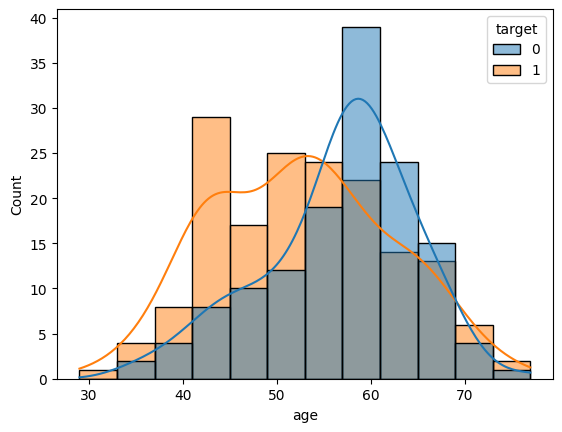

In [ ]:
sns.histplot(data=df, x="age",kde = True, hue="target") # Visualize age distribution based on heart disease target

<Axes: xlabel='age', ylabel='Count'>

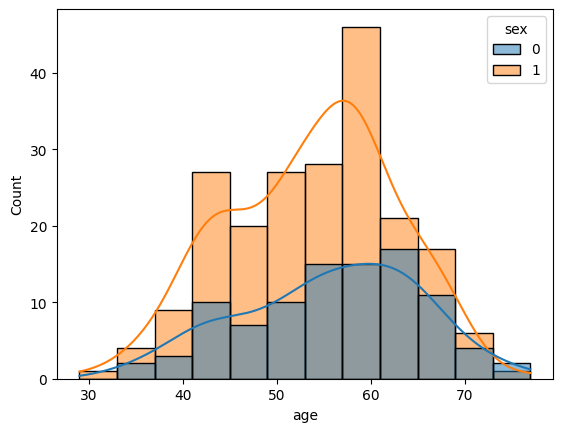

In [ ]:
# visualize heart disease based on sex
sns.histplot(data=df, x="age",kde = True, hue="sex") # Visualize age distribution based on sex

In [ ]:
# model training
x = df.drop("target", axis=1) # Separate features (x) by dropping the 'target' column
y = df["target"] # Assign the 'target' column as the label (y)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3, random_state = 42) # Split the data into training and testing sets

In [ ]:
model = LogisticRegression() # Initialize the Logistic Regression model
model.fit(x_train, y_train) # Train the model using the training data

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
ypre = model.predict(x_test) # Make predictions on the test set
ypre # Display the predicted values

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1])

In [ ]:
print(confusion_matrix(y_test, ypre)) # Print the confusion matrix to evaluate model performance

[[32  9]
 [ 8 42]]


In [ ]:
print(classification_report(y_test, ypre)) # Print the classification report to get precision, recall, f1-score

              precision    recall  f1-score   support

           0       0.80      0.78      0.79        41
           1       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91



In [ ]:
# finding if the model is overfitting or underfitting
print("traning eff: ", model.score(x_train, y_train)) # Calculate and print training accuracy
print("testing eff: ", model.score(x_test, y_test)) # Calculate and print testing accuracy

traning eff:  0.8679245283018868
testing eff:  0.8131868131868132


In [ ]:
new_data = df.iloc[:1,:-1] # Select the first row of the DataFrame as new data for prediction
pred = model.predict(new_data)[0] # Make a prediction on the new data
pred # Display the prediction

np.int64(1)